# DSV vest — multi-view ChArUco measurement

Take the set of worn-vest photos (front / back / side), run the **production
calibration technique** on each, return body measurements, and draw the
reference lines used for every number back onto the photo.

This notebook is a thin driver around `pipeline/measure/vest_charuco.py` — the
**single source of truth** for the calibration math (validated to ~1.5% on the
size-12 form). We do not re-implement the algorithm here; we call its internals
so the marker detection, grid-texture silhouette, anthropometric band snap and
the `VEST_CALIBRATION_FACTOR` are exactly what the API ships.

**Technique, per view**
1. detect the 14 unique ChArUco boards → per-landmark center + local px/mm (inner marker = 9 mm)
2. segment the garment from grid-texture energy, keep the marker blob
3. snap each band to its anthropometric extremum near the marker (bust = widest, waist = narrowest, hip = widest)
4. front edge-to-edge **width → circular girth × calibration factor** (the trusted number)
5. side front-back **depth** + front width → Ramanujan **ellipse girth** (secondary; needs a clean square profile)

**Honest scope:** front girths are the trusted output. Side depth and lengths
are first-pass — they depend on a square-on capture. Treat the marker-scale
spread as the error signal.

In [1]:
# --- setup: reach the pipeline package, import the production module ----------
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

# notebooks/ lives in Backend/cv_spike/ ; add the repo root so we can import
# pipeline.measure.vest_charuco (the deployed calibration module).
NB_DIR = Path.cwd()
CV_SPIKE = NB_DIR if (NB_DIR / "pipeline").is_dir() else NB_DIR.parent
sys.path.insert(0, str(CV_SPIKE))

from pipeline.measure import vest_charuco as vc  # noqa: E402

sys.path.insert(0, str(NB_DIR if (NB_DIR / "dsv_pose_measure.py").is_file()
                       else CV_SPIKE / "notebooks"))
import dsv_pose_measure as pm  # noqa: E402

USE_POSE_BACKEND = pm.mediapipe_available()
print("vest_charuco loaded from:", vc.__file__)
print("calibration factor:", vc.VEST_CALIBRATION_FACTOR)
print("marker scheme     :", ", ".join(vc.VEST_MARKER_NAMES))
print("pose backend (MediaPipe person mask + landmarks):",
      "ENABLED" if USE_POSE_BACKEND else "unavailable -> grid-texture fallback")

vest_charuco loaded from: /Users/debargha/Desktop/swaya/Backend/cv_spike/pipeline/measure/vest_charuco.py
calibration factor: 1.04
marker scheme     : FSH_L, FSH_R, FB, FW, FH, SR_U, SR_L, SL_U, SL_L, BSH_L, BSH_R, UB, MB, LB
pose backend (MediaPipe person mask + landmarks): ENABLED


## Config

`INPUT_DIR` is a folder of vest photos (jpg/png/jpeg). Each image is classified
into a view by which markers it shows — no naming convention required.
`GROUND_TRUTH` (optional) is tape truth for the validation cell at the end.

In [2]:
import os
# Point at any folder of vest photos. Override without editing: set DSV_INPUT_DIR.
INPUT_DIR = Path(os.environ.get("DSV_INPUT_DIR",
                                CV_SPIKE.parent.parent / "assets" / "DSV_1" / "jpg"))
OUT_DIR   = Path(os.environ.get("DSV_OUT_DIR", INPUT_DIR.parent / "measure_multiview"))
OUT_DIR.mkdir(parents=True, exist_ok=True)

CALIBRATION_FACTOR = vc.VEST_CALIBRATION_FACTOR   # override here to experiment

# Tape ground truth (cm circumference). Override with DSV_TRUTH='{"bust":91.4,...}'.
GROUND_TRUTH_CM = {"bust": 97.8, "waist": 76.2, "hip": 102.9}
if os.environ.get("DSV_TRUTH"):
    import json as _json
    GROUND_TRUTH_CM = _json.loads(os.environ["DSV_TRUTH"])

IMAGES = sorted(p for p in INPUT_DIR.iterdir()
                if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
print(f"{len(IMAGES)} image(s) in {INPUT_DIR}:")
for p in IMAGES:
    print("  ", p.name)

4 image(s) in /Users/debargha/Desktop/swaya/assets/DSV_1/jpg:
   IMG_0226.jpg
   IMG_0228.jpg
   IMG_0229.jpg
   IMG_0230.jpg


## Measurement + annotation

`measure_and_annotate(img)` runs the `vest_charuco` technique on one photo and
returns both the numbers and the geometry needed to draw the reference lines.
It reuses `vc.detect_markers / segment_garment / _refine_band / _band_extent /
circular_girth_cm` so the math stays identical to the deployed module.

In [3]:
FRONT = {"FB": "bust", "FW": "waist", "FH": "hip"}
SIDE_SLOT = {"SL_U": "upper", "SR_U": "upper", "SL_L": "lower", "SR_L": "lower"}
BACK_MARKERS = ("BSH_L", "BSH_R", "UB", "MB", "LB")

C_MARK  = (0, 200, 0)     # markers (BGR)
C_GIRTH = (0, 60, 230)    # front width / girth lines
C_DEPTH = (230, 90, 0)    # side depth lines
C_LEN   = (200, 0, 200)   # vertical length lines


def _mask_quality(mask, border_frac_max=0.30, area_frac_max=0.70):
    """Flag a leaked mask: a clean garment silhouette does not flood the frame.

    Returns (ok, warnings). The grid-texture segmentation breaks when the
    background resembles the fabric — the mask then fills the image and touches
    its borders, so any width/depth read off it is the frame, not the body.
    """
    h, w = mask.shape
    border = np.concatenate([mask[0], mask[-1], mask[:, 0], mask[:, -1]])
    border_frac = float(border.mean())          # share of border pixels in mask
    area_frac = float(mask.mean())              # share of whole frame in mask
    warns = []
    if border_frac > border_frac_max:
        warns.append(f"mask_touches_border ({border_frac:.0%})")
    if area_frac > area_frac_max:
        warns.append(f"mask_fills_frame ({area_frac:.0%})")
    return (not warns), warns


def classify_view(det):
    counts = {
        "front": sum(k in det for k in ("FB", "FW", "FH", "FSH_L", "FSH_R")),
        "side":  sum(k in det for k in SIDE_SLOT),
        "back":  sum(k in det for k in BACK_MARKERS),
    }
    view = max(counts, key=counts.get)
    return (view if counts[view] else "unknown"), counts


def _band_width(mask, det, marker, band, factor):
    """Snap to the anthropometric extremum near a front band marker."""
    c, scale = det[marker]["center"], det[marker]["px_per_mm"]
    r = vc._BAND_REFINE[band]
    snap = vc._refine_band(mask, int(c[1]), int(c[0]), scale,
                           r["dy_lo_mm"], r["dy_hi_mm"], r["mode"])
    if snap:
        y, xl, xr = snap
    else:
        ext = vc._band_extent(mask, int(c[1]), int(c[0]))
        if not ext:
            return None
        y, (xl, xr) = int(c[1]), ext
    width_cm = (xr - xl) / scale / 10.0
    return {"y": y, "xl": xl, "xr": xr, "scale": scale, "width_cm": width_cm}


def measure_and_annotate(img_bgr, factor=CALIBRATION_FACTOR):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    det = vc.detect_markers(gray)
    view, counts = classify_view(det)
    rec = {"view": view, "marker_counts": counts, "markers": sorted(det),
           "measurements": {}, "lines": [], "points": [], "warnings": []}
    if not det:
        return img_bgr.copy(), rec

    # --- segmentation backend: MediaPipe person mask (robust to background),
    #     falling back to the grid-texture heuristic when pose isn't available.
    pose_mask, lms = None, None
    if USE_POSE_BACKEND:
        try:
            pose_mask, lms = pm.detect_pose_and_mask(img_bgr)
        except Exception as e:  # noqa: BLE001
            rec["warnings"].append(f"pose_backend_failed:{type(e).__name__}")
    if pose_mask is not None:
        mask, rec["segmentation"] = pose_mask, "mediapipe_pose"
    else:
        mask = vc.segment_garment(img_bgr, [d["center"] for d in det.values()])
        rec["segmentation"] = "grid_texture"
    rec["mask_ok"], warns = _mask_quality(mask)
    rec["warnings"].extend(warns)
    for nm, d in det.items():
        rec["points"].append((tuple(int(v) for v in d["center"]), nm))

    if view == "front":
        cx = int(np.mean([d["center"][0] for d in det.values()]))
        for marker, band in FRONT.items():
            if marker not in det:
                continue
            c, scale = det[marker]["center"], det[marker]["px_per_mm"]
            arm_clipped = None
            if lms is not None:                       # pose-aware, arm-excluded
                ext = pm.torso_extent(mask, lms, int(c[1]), cx)
                if ext:
                    xl, xr, arm_clipped = ext
                    y = int(c[1])
                else:
                    arm_clipped = None
                    y = xl = xr = None
            if arm_clipped is None:                   # grid-texture fallback
                b = _band_width(mask, det, marker, band, factor)
                if not b:
                    continue
                y, xl, xr = b["y"], b["xl"], b["xr"]
            width_cm = (xr - xl) / scale / 10.0
            girth = vc.circular_girth_cm(width_cm, factor)
            m = {"width_cm": round(width_cm, 1),
                 "girth_cm": round(girth, 1), "girth_in": round(girth / 2.54, 1),
                 "kind": "girth", "method": "front circular x calib"}
            if arm_clipped:
                m["arm_occluded"] = True              # edge may be arm, not body
            rec["measurements"][band] = m
            col = C_GIRTH if not arm_clipped else (0, 160, 255)
            lbl = f"{band} W={width_cm:.1f}cm  G={girth:.1f}cm" + (" [arm?]" if arm_clipped else "")
            rec["lines"].append(((xl, y), (xr, y), col, lbl))
        if "FSH_L" in det and "FSH_R" in det:
            cl, cr = det["FSH_L"]["center"], det["FSH_R"]["center"]
            y, cx = int((cl[1] + cr[1]) / 2), int((cl[0] + cr[0]) / 2)
            sc = (det["FSH_L"]["px_per_mm"] + det["FSH_R"]["px_per_mm"]) / 2
            ext = vc._band_extent(mask, y, cx)
            if ext:
                w = (ext[1] - ext[0]) / sc / 10.0
                rec["measurements"]["shoulder_width"] = {"width_cm": round(w, 1), "kind": "width"}
                rec["lines"].append(((ext[0], y), (ext[1], y), C_GIRTH, f"shoulder W={w:.1f}cm"))
        if ("FSH_L" in det or "FSH_R" in det) and "FH" in det:
            tops = [det[m] for m in ("FSH_L", "FSH_R") if m in det]
            ty = int(sum(t["center"][1] for t in tops) / len(tops))
            tx = int(sum(t["center"][0] for t in tops) / len(tops))
            by, sc = int(det["FH"]["center"][1]), det["FH"]["px_per_mm"]
            L = abs(by - ty) / sc / 10.0
            rec["measurements"]["front_length"] = {"length_cm": round(L, 1), "kind": "length"}
            rec["lines"].append(((tx, ty), (tx, by), C_LEN, f"front len={L:.1f}cm"))

    elif view == "side":
        for marker, slot in SIDE_SLOT.items():
            if marker not in det:
                continue
            c, sc = det[marker]["center"], det[marker]["px_per_mm"]
            ext = vc._band_extent(mask, int(c[1]), int(c[0]))
            if not ext:
                continue
            depth_cm = (ext[1] - ext[0]) / sc / 10.0
            rec["measurements"].setdefault("depths", {}).setdefault(slot, []).append(round(depth_cm, 1))
            rec["lines"].append(((ext[0], int(c[1])), (ext[1], int(c[1])), C_DEPTH,
                                 f"{slot} depth={depth_cm:.1f}cm"))

    elif view == "back":
        if "BSH_L" in det and "BSH_R" in det:
            cl, cr = det["BSH_L"]["center"], det["BSH_R"]["center"]
            y, cx = int((cl[1] + cr[1]) / 2), int((cl[0] + cr[0]) / 2)
            sc = (det["BSH_L"]["px_per_mm"] + det["BSH_R"]["px_per_mm"]) / 2
            ext = vc._band_extent(mask, y, cx)
            if ext:
                w = (ext[1] - ext[0]) / sc / 10.0
                rec["measurements"]["back_shoulder_width"] = {"width_cm": round(w, 1), "kind": "width"}
                rec["lines"].append(((ext[0], y), (ext[1], y), C_GIRTH, f"back shoulder W={w:.1f}cm"))
        if "UB" in det:
            c, sc = det["UB"]["center"], det["UB"]["px_per_mm"]
            ext = vc._band_extent(mask, int(c[1]), int(c[0]))
            if ext:
                w = (ext[1] - ext[0]) / sc / 10.0
                rec["measurements"]["upper_back_width"] = {"width_cm": round(w, 1), "kind": "width"}
                rec["lines"].append(((ext[0], int(c[1])), (ext[1], int(c[1])), C_GIRTH, f"upper back W={w:.1f}cm"))
        if ("BSH_L" in det or "BSH_R" in det) and "LB" in det:
            tops = [det[m] for m in ("BSH_L", "BSH_R") if m in det]
            ty = int(sum(t["center"][1] for t in tops) / len(tops))
            tx = int(sum(t["center"][0] for t in tops) / len(tops))
            by, sc = int(det["LB"]["center"][1]), det["LB"]["px_per_mm"]
            L = abs(by - ty) / sc / 10.0
            rec["measurements"]["back_length"] = {"length_cm": round(L, 1), "kind": "length"}
            rec["lines"].append(((tx, ty), (tx, by), C_LEN, f"back len={L:.1f}cm"))

    scales = [d["px_per_mm"] for d in det.values()]
    rec["scale_px_per_mm"] = round(float(np.median(scales)), 2)
    rec["scale_spread"] = round(float(np.std(scales)), 2)

    vis = _draw(img_bgr, mask, rec)
    return vis, rec


def _draw(img_bgr, mask, rec):
    vis = img_bgr.copy()
    vis[mask > 0] = (0.7 * vis[mask > 0] + 0.3 * np.array([0, 160, 0])).astype(np.uint8)
    w = vis.shape[1]
    fs = max(0.8, w / 1500.0)
    th = max(2, w // 700)
    for (p1, p2, color, label) in rec["lines"]:
        cv2.line(vis, p1, p2, color, th, cv2.LINE_AA)
        tx, ty = min(p1[0], p2[0]), min(p1[1], p2[1]) - 10
        cv2.putText(vis, label, (tx, ty), cv2.FONT_HERSHEY_SIMPLEX, fs, color, th, cv2.LINE_AA)
    for (c, nm) in rec["points"]:
        cv2.circle(vis, c, int(8 * fs), C_MARK, th)
        cv2.putText(vis, nm, (c[0] + int(10 * fs), c[1]), cv2.FONT_HERSHEY_SIMPLEX,
                    fs * 0.8, C_MARK, max(1, th - 1), cv2.LINE_AA)
    return vis

## Run on every image

Each photo is measured and the reference lines drawn on it, shown inline.

I0000 00:00:1781190044.275589   98581 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 11, prefix = pthread-default
I0000 00:00:1781190044.315306   98581 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781190044.345993   98586 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781190044.352098   98584 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


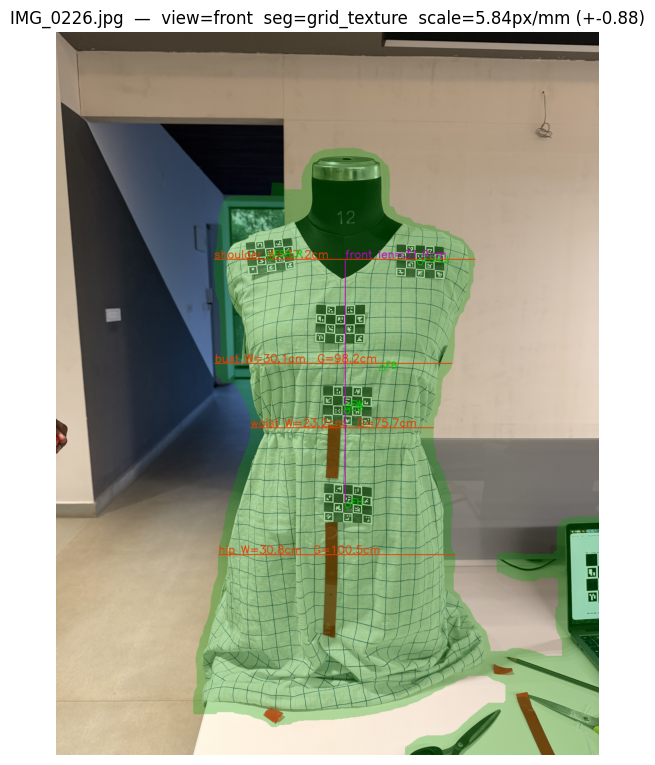

IMG_0226.jpg: view=front  markers=['FB', 'FH', 'FSH_L', 'FSH_R', 'FW', 'UB']
    bust                 {'width_cm': 30.1, 'girth_cm': 98.2, 'girth_in': 38.7, 'kind': 'girth', 'method': 'front circular x calib'}
    waist                {'width_cm': 23.2, 'girth_cm': 75.7, 'girth_in': 29.8, 'kind': 'girth', 'method': 'front circular x calib'}
    hip                  {'width_cm': 30.8, 'girth_cm': 100.5, 'girth_in': 39.6, 'kind': 'girth', 'method': 'front circular x calib'}
    shoulder_width       {'width_cm': 37.2, 'kind': 'width'}
    front_length         {'length_cm': 31.9, 'kind': 'length'}


I0000 00:00:1781190045.673203   98602 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1781190045.703890   98605 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781190045.708716   98612 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


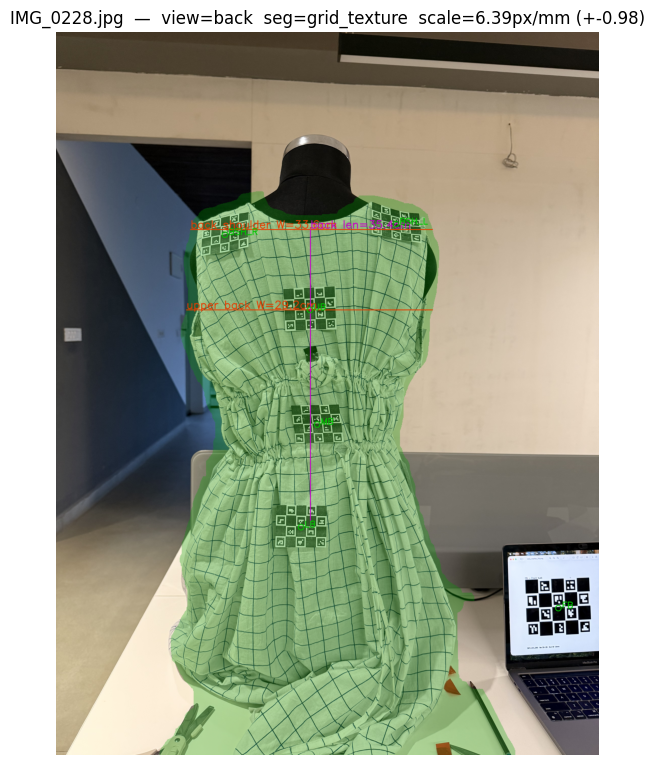

IMG_0228.jpg: view=back  markers=['BSH_L', 'BSH_R', 'FB', 'LB', 'MB', 'UB']
    back_shoulder_width  {'width_cm': 33.6, 'kind': 'width'}
    upper_back_width     {'width_cm': 29.2, 'kind': 'width'}
    back_length          {'length_cm': 35.4, 'kind': 'length'}


I0000 00:00:1781190047.259734   98618 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1781190047.294055   98621 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781190047.300518   98624 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


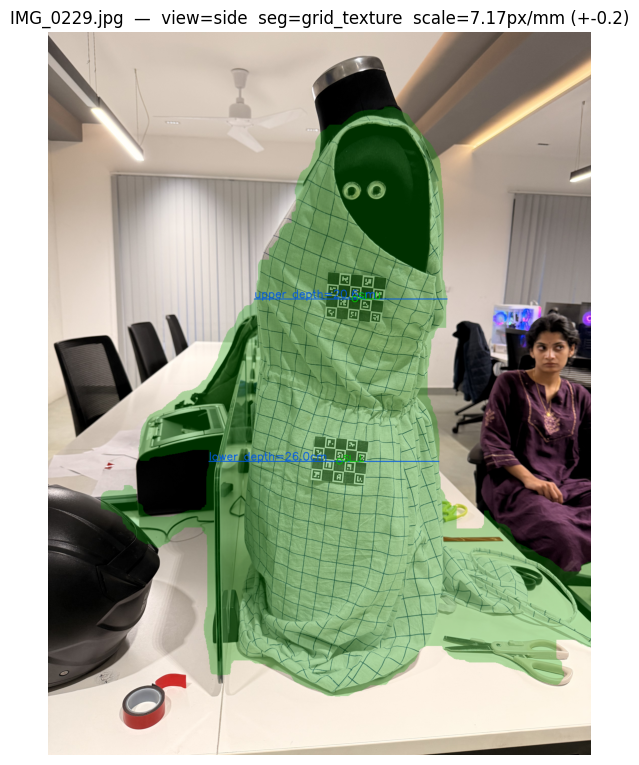

IMG_0229.jpg: view=side  markers=['SL_L', 'SL_U']
    depths               {'upper': [20.6], 'lower': [26.0]}


I0000 00:00:1781190048.428213   98653 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1781190048.460768   98656 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781190048.465652   98656 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


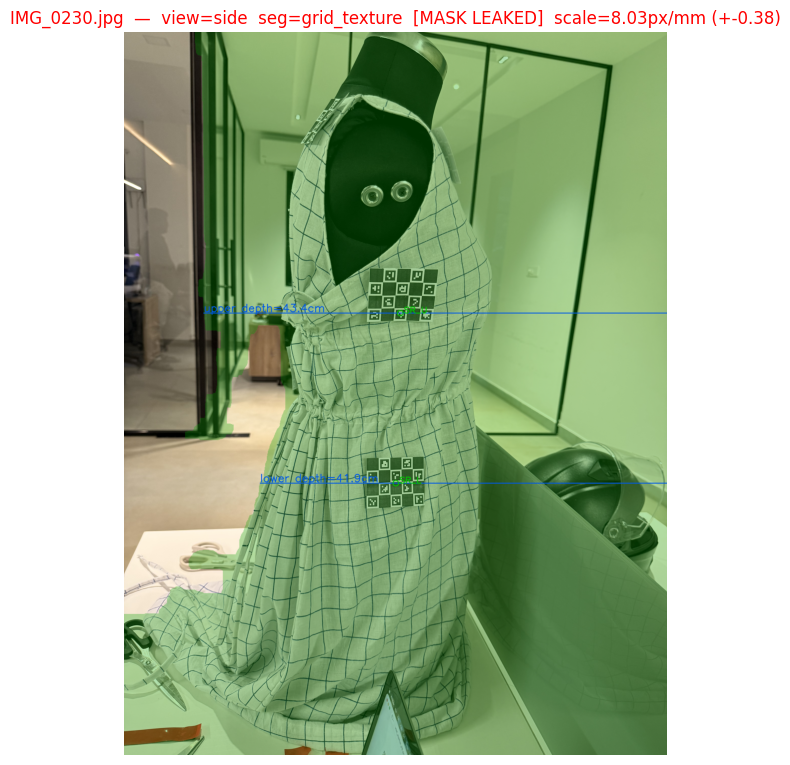

IMG_0230.jpg: view=side  markers=['SR_L', 'SR_U']
    !! segmentation: mask_touches_border (74%), mask_fills_frame (86%) -> measurements untrusted
    depths               {'upper': [43.4], 'lower': [41.9]}


In [4]:
records = {}
annotated = {}
for p in IMAGES:
    img = cv2.imread(str(p))
    if img is None:
        print(f"skip (unreadable): {p.name}")
        continue
    vis, rec = measure_and_annotate(img)
    records[p.name] = rec
    annotated[p.name] = vis

    fig, ax = plt.subplots(figsize=(7, 10))
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    flag = "" if rec.get("mask_ok", True) else "  [MASK LEAKED]"
    seg = rec.get("segmentation", "?")
    ax.set_title(f"{p.name}  —  view={rec['view']}  seg={seg}{flag}  "
                 f"scale={rec.get('scale_px_per_mm')}px/mm (+-{rec.get('scale_spread')})",
                 color=("black" if rec.get("mask_ok", True) else "red"))
    ax.axis("off")
    plt.show()

    print(f"{p.name}: view={rec['view']}  markers={rec['markers']}")
    if rec.get("warnings"):
        print(f"    !! segmentation: {', '.join(rec['warnings'])} -> measurements untrusted")
    for name, m in rec["measurements"].items():
        print(f"    {name:20s} {m}")

## Marker-to-marker fallback (scale-only)

When the silhouette is unusable (leaked mask, occluded body, busy background)
but ≥2 markers are detected, we can still report **landmark-to-landmark
distances** straight from the marker centers and their known size — no
segmentation required. Distances are within a single image only (each view has
its own scale/framing). Oblique shots foreshorten, so treat these as first-pass.

In [5]:
PAIRS = [
    ("FSH_L", "FSH_R", "front shoulder span"),
    ("FB", "FW", "bust->waist drop"),
    ("FW", "FH", "waist->hip drop"),
    ("FB", "FH", "bust->hip drop"),
    ("BSH_L", "BSH_R", "back shoulder span"),
    ("UB", "MB", "upper->mid back"),
    ("MB", "LB", "mid->lower back"),
    ("UB", "LB", "upper->lower back"),
    ("SL_U", "SL_L", "left side upper->lower"),
    ("SR_U", "SR_L", "right side upper->lower"),
]


def marker_distances(det):
    out = []
    for a, b, label in PAIRS:
        if a in det and b in det:
            pa, pb = det[a]["center"], det[b]["center"]
            dpx = float(np.hypot(*(pa - pb)))
            scale = (det[a]["px_per_mm"] + det[b]["px_per_mm"]) / 2.0
            if scale > 0:
                out.append({"from": a, "to": b, "label": label,
                            "cm": round(dpx / scale / 10.0, 1),
                            "in": round(dpx / scale / 25.4, 1)})
    return out


distances = {}
for p in IMAGES:
    img = cv2.imread(str(p))
    if img is None:
        continue
    det = vc.detect_markers(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))
    dist = marker_distances(det)
    if dist:
        distances[p.name] = dist

if distances:
    print("marker-to-marker distances (scale-only, segmentation-independent):")
    for name, dist in distances.items():
        print(f"  {name}:")
        for d in dist:
            print(f"    {d['label']:24s} {d['from']}->{d['to']}  {d['cm']} cm ({d['in']} in)")
else:
    print("No image has >=2 markers in the same view -> no marker-distance pairs available.")

marker-to-marker distances (scale-only, segmentation-independent):
  IMG_0226.jpg:
    front shoulder span      FSH_L->FSH_R  21.5 cm (8.4 in)
    bust->waist drop         FB->FW  6.6 cm (2.6 in)
    waist->hip drop          FW->FH  12.6 cm (4.9 in)
    bust->hip drop           FB->FH  18.1 cm (7.1 in)
  IMG_0228.jpg:
    back shoulder span       BSH_L->BSH_R  23.8 cm (9.4 in)
    upper->mid back          UB->MB  14.2 cm (5.6 in)
    mid->lower back          MB->LB  12.8 cm (5.1 in)
    upper->lower back        UB->LB  25.8 cm (10.2 in)
  IMG_0229.jpg:
    left side upper->lower   SL_U->SL_L  17.9 cm (7.1 in)
  IMG_0230.jpg:
    right side upper->lower  SR_U->SR_L  16.7 cm (6.6 in)


## Aggregate measurements

Front girths are the trusted output. Where a side view supplied a depth at the
matching slot, we also report an **ellipse girth** (secondary) via `vc.ellipse_girth_cm`.

In [6]:
# trusted front girths (only from views whose mask passed the quality guard)
final = {}
for rec in records.values():
    if rec["view"] != "front" or not rec.get("mask_ok", True):
        continue
    for band in ("bust", "waist", "hip"):
        if band in rec["measurements"]:
            final[band] = dict(rec["measurements"][band])

# side depths -> ellipse girth (bust<-upper, hip<-lower, waist<-mean).
# Skip any view whose mask leaked into the background.
depths = {"upper": [], "lower": []}
skipped = []
for name, rec in records.items():
    if not rec.get("mask_ok", True):
        if rec["measurements"].get("depths"):
            skipped.append(name)
        continue
    for slot, vals in rec["measurements"].get("depths", {}).items():
        depths[slot].extend(vals)
if skipped:
    print(f"excluded leaked side mask(s) from depth/ellipse: {skipped}\n")
up = float(np.median(depths["upper"])) if depths["upper"] else None
lo = float(np.median(depths["lower"])) if depths["lower"] else None
band_depth = {"bust": up, "hip": lo,
              "waist": (np.mean([up, lo]) if up and lo else (up or lo))}

for band in ("bust", "waist", "hip"):
    d, f = band_depth.get(band), final.get(band)
    if f and d:
        eg = vc.ellipse_girth_cm(f["width_cm"], d, CALIBRATION_FACTOR)
        f["depth_cm"] = round(d, 1)
        f["ellipse_girth_cm"] = round(eg, 1)
        f["ellipse_girth_in"] = round(eg / 2.54, 1)

print(f"{'band':8s} {'circ girth':>12s} {'ellipse':>10s} {'width':>8s} {'depth':>8s}")
for band in ("bust", "waist", "hip"):
    f = final.get(band, {})
    print(f"{band:8s} "
          f"{f.get('girth_cm','-'):>12} "
          f"{f.get('ellipse_girth_cm','-'):>10} "
          f"{f.get('width_cm','-'):>8} "
          f"{f.get('depth_cm','-'):>8}")

# secondary measurements (widths / lengths) from front + back
extra = {}
for rec in records.values():
    for name, m in rec["measurements"].items():
        if name in ("bust", "waist", "hip", "depths"):
            continue
        extra[name] = m
print("\nother measurements:")
for name, m in extra.items():
    print(f"  {name:22s} {m}")

excluded leaked side mask(s) from depth/ellipse: ['IMG_0230.jpg']

band       circ girth    ellipse    width    depth
bust             98.2       83.6     30.1     20.6
waist            75.7       76.0     23.2     23.3
hip             100.5       93.0     30.8     26.0

other measurements:
  shoulder_width         {'width_cm': 37.2, 'kind': 'width'}
  front_length           {'length_cm': 31.9, 'kind': 'length'}
  back_shoulder_width    {'width_cm': 33.6, 'kind': 'width'}
  upper_back_width       {'width_cm': 29.2, 'kind': 'width'}
  back_length            {'length_cm': 35.4, 'kind': 'length'}


## Validation vs tape ground truth (optional)

Compares the trusted circular girths to `GROUND_TRUTH_CM` if provided.

In [7]:
if GROUND_TRUTH_CM:
    print(f"{'band':8s} {'est cm':>8s} {'true cm':>8s} {'err %':>8s}")
    for band, true_cm in GROUND_TRUTH_CM.items():
        est = final.get(band, {}).get("girth_cm")
        if est is None:
            print(f"{band:8s} {'-':>8} {true_cm:>8.1f} {'n/a':>8}")
            continue
        err = 100.0 * (est - true_cm) / true_cm
        print(f"{band:8s} {est:>8.1f} {true_cm:>8.1f} {err:>+7.1f}%")
else:
    print("GROUND_TRUTH_CM empty — skipping validation.")

band       est cm  true cm    err %
bust         98.2     97.8    +0.4%
waist        75.7     76.2    -0.7%
hip         100.5    102.9    -2.3%


## Save outputs

Annotated photos + a single `measurements.json` to `OUT_DIR`.

In [8]:
import json

for name, vis in annotated.items():
    stem = Path(name).stem
    cv2.imwrite(str(OUT_DIR / f"{stem}_annotated.jpg"), vis, [cv2.IMWRITE_JPEG_QUALITY, 88])

payload = {
    "calibration_factor": CALIBRATION_FACTOR,
    "source": "pipeline.measure.vest_charuco",
    "final_girths": final,
    "other_measurements": extra,
    "marker_distances": distances,
    "per_image": {n: {k: v for k, v in r.items() if k not in ("lines", "points")}
                  for n, r in records.items()},
}
(OUT_DIR / "measurements.json").write_text(json.dumps(payload, indent=2, default=float), encoding="utf-8")
print("wrote:")
for p in sorted(OUT_DIR.iterdir()):
    print("  ", p)

wrote:
   /Users/debargha/Desktop/swaya/assets/DSV_1/measure_multiview/IMG_0226_annotated.jpg
   /Users/debargha/Desktop/swaya/assets/DSV_1/measure_multiview/IMG_0228_annotated.jpg
   /Users/debargha/Desktop/swaya/assets/DSV_1/measure_multiview/IMG_0229_annotated.jpg
   /Users/debargha/Desktop/swaya/assets/DSV_1/measure_multiview/IMG_0230_annotated.jpg
   /Users/debargha/Desktop/swaya/assets/DSV_1/measure_multiview/measurements.json
